In [1]:
# ══════════════════════════════════════════════════════════════════
# NB04 — Sentiment Analysis
# The Platform Shift: A Deep Dive
# ══════════════════════════════════════════════════════════════════
#
# Three-tier sentiment pipeline:
#   Block 1 — VADER       : full corpus (~224k reviews), English lexicon
#   Block 2 — DistilBERT  : stratified English sample, higher accuracy
#   Block 3 — Claude API  : full multilingual corpus, semantic themes
#
# Multilingual note:
#   English reviews are 30–55% of corpus depending on publisher.
#   VADER and DistilBERT are English-only — multilingual reviews score
#   neutral (compound ≈ 0) and dilute publisher averages.
#   Block 3 (Claude API) is the analytically differentiated tier:
#   it handles Russian, Chinese, Turkish, Brazilian Portuguese natively.
#
# Environment note:
#   Parquet skipped — pyarrow conda/pip conflict in platform_shift env.
#   CSV used throughout. No analytical impact. Flagged for NB07.
#
# Inputs:
#   ../data/raw/reviews/*.json
#   ../data/processed/NB02_revenue_data.csv
#   ../data/processed/NB02_revenue_pivot.csv
#
# Outputs:
#   ../data/processed/NB04_vader_scores.csv
#   ../data/processed/NB04_distilbert_scores.csv
#   ../data/processed/NB04_claude_themes.csv       (Block 3)
#   ../data/processed/NB04_sentiment_summary.csv
#   ../data/processed/NB04_sentiment_chart.png
#
# Notebook map:
#   Cell 1  — Config & imports
#   Cell 2  — Load registry + corpus index + revenue CAGR
#   Cell 3  — Corpus language composition
#   Cell 4  — Block 1: VADER scoring (full corpus)
#   Cell 5  — Block 1: VADER publisher + title summary
#   Cell 6  — Block 2: DistilBERT scoring (stratified English sample)
#   Cell 7  — Block 2: DistilBERT summary + VADER agreement
#   Cell 8  — Block 3: Claude API multilingual theme extraction
#   Cell 9  — Unified sentiment table
#   Cell 10 — Visualization
#   Cell 11 — Save outputs
#   Cell 12 — NB04 Observation
# ══════════════════════════════════════════════════════════════════

# ── CELL 1: Config ────────────────────────────────────────────────
USE_CACHE        = True
SAMPLE_PER_TITLE = 500    # DistilBERT stratified sample per title
BATCH_SIZE       = 32     # DistilBERT batch size — reduce to 8 if OOM
MAX_TEXT_LEN     = 512    # DistilBERT token limit
CLAUDE_SAMPLE    = 50     # Reviews per title for Claude API tier

import sys
import warnings
import importlib
import json
from pathlib import Path
warnings.filterwarnings('ignore')

PROJECT_ROOT = Path('../').resolve()
RAW_REVIEWS  = PROJECT_ROOT / 'data' / 'raw' / 'reviews'
PROCESSED    = PROJECT_ROOT / 'data' / 'processed'
sys.path.insert(0, str(PROJECT_ROOT / 'extractors'))

import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D

VADER_CACHE      = PROCESSED / 'NB04_vader_scores.csv'
DISTILBERT_CACHE = PROCESSED / 'NB04_distilbert_scores.csv'
CLAUDE_CACHE     = PROCESSED / 'NB04_claude_themes.csv'

# JP font
for font in ['MS Gothic', 'Yu Gothic', 'Meiryo', 'IPAGothic']:
    try:
        matplotlib.font_manager.findfont(font, fallback_to_default=False)
        matplotlib.rcParams['font.family'] = font
        break
    except Exception:
        continue

plt.rcParams.update({
    'font.family':      'Segoe UI',
    'font.size':        10,
    'figure.facecolor': '#0F1117',
    'axes.facecolor':   '#252836',
    'axes.edgecolor':   '#2D3148',
    'axes.labelcolor':  '#CCCCCC',
    'xtick.color':      '#CCCCCC',
    'ytick.color':      '#CCCCCC',
    'text.color':       '#FFFFFF',
    'grid.color':       '#2D3148',
    'legend.facecolor': '#1F2937',
    'legend.edgecolor': '#374151',
})

PUBLISHER_COLORS = {
    'sie':          '#E8780A',
    'bandai_namco': '#C8A800',
    'sega_atlus':   '#4A90D9',
    'square_enix':  '#E4002B',
    'nintendo':     '#E4000F',
    'ea':           '#D63800',
    'take_two':     '#2B5BB5',
    'ubisoft':      '#6B7A8D',
}

DISPLAY_NAMES = {
    'sie':          'SIE',
    'bandai_namco': 'Bandai Namco',
    'sega_atlus':   'Sega/Atlus',
    'square_enix':  'Square Enix',
    'nintendo':     'Nintendo',
    'ea':           'EA',
    'take_two':     'Take-Two',
    'ubisoft':      'Ubisoft',
}

JP_TARGETS   = ['sie', 'bandai_namco', 'sega_atlus', 'square_enix']
JP_BENCHMARK = ['nintendo']
WESTERN      = ['ea', 'take_two', 'ubisoft']
ALL_GROUPS   = JP_TARGETS + JP_BENCHMARK + WESTERN

NB02_TO_NB01 = {
    'sony': 'sie', 'bandai_namco': 'bandai_namco',
    'sega_sammy': 'sega_atlus', 'square_enix': 'square_enix',
    'nintendo': 'nintendo', 'ea': 'ea',
    'take_two': 'take_two', 'ubisoft': 'ubisoft',
}

print('NB04 config loaded')
print(f'RAW_REVIEWS : {RAW_REVIEWS}')
print(f'PROCESSED   : {PROCESSED}')
print(f'Sample/title: VADER=all | DistilBERT={SAMPLE_PER_TITLE} | Claude={CLAUDE_SAMPLE}')


NB04 config loaded
RAW_REVIEWS : C:\Users\stanl\OneDrive\Desktop\VSCode_Projects\2. ThePlatformShift_ADeepDive\data\raw\reviews
PROCESSED   : C:\Users\stanl\OneDrive\Desktop\VSCode_Projects\2. ThePlatformShift_ADeepDive\data\processed
Sample/title: VADER=all | DistilBERT=500 | Claude=50


In [2]:
# ── CELL 2: Load registry + corpus index + revenue CAGR ──────────
import game_registry
importlib.reload(game_registry)
from game_registry import GAME_REGISTRY

appid_to_publisher = {}
appid_to_title     = {}
for publisher, games in GAME_REGISTRY.items():
    for title, meta in games.items():
        aid = meta.get('appid')
        if aid:
            appid_to_publisher[int(aid)] = publisher
            appid_to_title[int(aid)]     = title

review_files = sorted(RAW_REVIEWS.glob('*.json'))
print(f'Review files found: {len(review_files)}')

total_reviews = 0
per_title     = []
for path in review_files:
    with open(path) as f:
        d = json.load(f)
    n     = len(d.get('reviews', []))
    appid = int(d.get('appid', 0))
    total_reviews += n
    per_title.append({
        'appid':     appid,
        'title':     appid_to_title.get(appid, str(appid)),
        'publisher': appid_to_publisher.get(appid, 'unknown'),
        'n_reviews': n,
    })

corpus_df = pd.DataFrame(per_title)
print(f'Total reviews in corpus: {total_reviews:,}')
print()
print('Reviews per publisher:')
print(corpus_df.groupby('publisher')['n_reviews']
      .sum().sort_values(ascending=False).to_string())

# Revenue CAGR
revenue_df = pd.read_csv(PROCESSED / 'NB02_revenue_data.csv')
pivot_raw  = pd.read_csv(PROCESSED / 'NB02_revenue_pivot.csv', index_col=0)
pivot_raw.columns = [int(c) if str(c).isdigit() else c for c in pivot_raw.columns]

def calc_cagr(row, start, end):
    if start not in row.index or end not in row.index:
        return None
    try:
        vs, ve = float(row[start]), float(row[end])
    except (TypeError, ValueError):
        return None
    if pd.isna(vs) or pd.isna(ve) or vs <= 0:
        return None
    return round(((ve / vs) ** (1 / (end - start)) - 1) * 100, 1)

cagr_map = {}
for company, row in pivot_raw.iterrows():
    pg = NB02_TO_NB01.get(company, company)
    cagr_map[pg] = calc_cagr(row, 2022, 2025) or calc_cagr(row, 2022, 2024)

print()
print('Revenue CAGR loaded:')
for pg, v in cagr_map.items():
    name = DISPLAY_NAMES.get(pg, pg)
    print(f'  {name:15s}: {v:+.1f}%' if v is not None else f'  {name:15s}: N/A')


Review files found: 46
Total reviews in corpus: 229,681

Reviews per publisher:
publisher
square_enix     55197
sie             50588
bandai_namco    39471
sega_atlus      38834
ubisoft         15296
take_two        15196
ea              15099

Revenue CAGR loaded:
  SIE            : +13.2%
  Nintendo       : -11.8%
  EA             : +12.2%
  Take-Two       : +29.9%
  Ubisoft        : +2.9%
  Bandai Namco   : +6.4%
  Sega/Atlus     : +10.9%
  Square Enix    : -2.0%


In [3]:
# ── CELL 3: Corpus language composition ──────────────────────────
# English reviews are 30–55% of corpus depending on publisher.
# This is a first-order analytical concern: VADER and DistilBERT
# are English-only models — non-English reviews score neutral (0.0)
# and dilute publisher-level averages.
#
# Key implication: Block 3 (Claude API) handles the multilingual
# majority and is the analytically differentiated tier.

if VADER_CACHE.exists():
    vader_lang = pd.read_csv(VADER_CACHE, usecols=['publisher_group', 'language'])
    lang_split = (
        vader_lang.groupby(['publisher_group', 'language'])
        .size()
        .reset_index(name='count')
    )
    lang_split['pct'] = (
        lang_split.groupby('publisher_group')['count']
        .transform(lambda x: x / x.sum() * 100)
        .round(1)
    )
    english_pct = (
        lang_split[lang_split['language'] == 'english']
        .set_index('publisher_group')[['pct']]
        .rename(columns={'pct': 'english_pct'})
    )
    print('── English review share by publisher ────────────────────')
    print(english_pct.sort_values('english_pct', ascending=False).to_string())
    print()
    print('Note: non-English reviews score compound ≈ 0.0 under VADER/DistilBERT.')
    print('      Block 3 (Claude API) is the only tier that scores these correctly.')
else:
    print('VADER cache not found — run Cell 4 first, then re-run this cell.')


── English review share by publisher ────────────────────
                 english_pct
publisher_group             
ubisoft                 54.8
sega_atlus              47.3
sie                     46.4
square_enix             46.3
bandai_namco            44.1
take_two                38.2
ea                      29.6

Note: non-English reviews score compound ≈ 0.0 under VADER/DistilBERT.
      Block 3 (Claude API) is the only tier that scores these correctly.


In [4]:
# ══════════════════════════════════════════════════════════════════
# BLOCK 1 — VADER Sentiment (full corpus)
# ══════════════════════════════════════════════════════════════════
# English-only lexicon. Non-English reviews score compound = 0.0.
# Runtime: ~3-5 min for ~228k reviews.
# ══════════════════════════════════════════════════════════════════

# ── CELL 4: VADER scoring ─────────────────────────────────────────
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

if USE_CACHE and VADER_CACHE.exists():
    print('Loading VADER scores from cache...')
    vader_df = pd.read_csv(VADER_CACHE)
    print(f'Loaded {len(vader_df):,} rows')
else:
    analyzer = SentimentIntensityAnalyzer()
    rows     = []

    print(f'Scoring {len(review_files)} titles (full corpus)...')
    for fi, path in enumerate(review_files):
        with open(path) as f:
            d = json.load(f)

        appid   = int(d.get('appid', 0))
        reviews = d.get('reviews', [])
        pub     = appid_to_publisher.get(appid, 'unknown')
        title   = appid_to_title.get(appid, str(appid))

        for rev in reviews:
            text = rev.get('review_text', '') or ''
            if not text.strip():
                continue
            scores = analyzer.polarity_scores(text[:5000])
            rows.append({
                'appid':            appid,
                'title':            title,
                'publisher_group':  pub,
                'recommendationid': rev.get('recommendationid'),
                'voted_up':         rev.get('voted_up'),
                'votes_up':         int(rev.get('votes_up', 0) or 0),
                'playtime_forever': int(rev.get('author_playtime_forever', 0) or 0),
                'language':         rev.get('language', ''),
                'text_len':         len(text),
                'vader_neg':        scores['neg'],
                'vader_neu':        scores['neu'],
                'vader_pos':        scores['pos'],
                'vader_compound':   scores['compound'],
            })

        if (fi + 1) % 10 == 0 or fi == len(review_files) - 1:
            print(f'  [{fi+1}/{len(review_files)}] {title}: {len(reviews)} reviews')

    vader_df = pd.DataFrame(rows)
    vader_df.to_csv(VADER_CACHE, index=False)
    print(f'\nSaved {len(vader_df):,} rows → {VADER_CACHE}')

print(f'\nVADER corpus : {len(vader_df):,} reviews | '
      f'{vader_df["publisher_group"].nunique()} publishers | '
      f'{vader_df["appid"].nunique()} titles')


Loading VADER scores from cache...
Loaded 228,776 rows

VADER corpus : 228,776 reviews | 7 publishers | 46 titles


In [5]:
# ── CELL 5: VADER publisher + title summary ───────────────────────

# Publisher-level
pub_vader = (
    vader_df
    .groupby('publisher_group')
    .agg(
        reviews         = ('vader_compound', 'count'),
        mean_compound   = ('vader_compound', 'mean'),
        median_compound = ('vader_compound', 'median'),
        pct_positive    = ('voted_up', 'mean'),
        mean_text_len   = ('text_len', 'mean'),
    )
    .round(3)
)
pub_vader['display_name'] = pub_vader.index.map(DISPLAY_NAMES)
pub_vader['revenue_cagr'] = pub_vader.index.map(cagr_map)
pub_vader = pub_vader.sort_values('mean_compound', ascending=False)

print('── VADER Publisher Summary (full corpus, all languages) ─────')
print(pub_vader[['display_name','reviews','mean_compound',
                  'median_compound','pct_positive',
                  'revenue_cagr']].to_string())

vader_cagr = pub_vader.dropna(subset=['revenue_cagr'])
if len(vader_cagr) >= 4:
    r = vader_cagr['mean_compound'].corr(
        vader_cagr['revenue_cagr'].astype(float))
    print(f'\nVADER compound vs revenue CAGR: Pearson r = {r:.3f}')
    print('(Caveat: mean_compound diluted by non-English reviews scoring 0.0)')

# Title-level
title_vader = (
    vader_df
    .groupby(['publisher_group', 'title'])
    .agg(
        reviews       = ('vader_compound', 'count'),
        mean_compound = ('vader_compound', 'mean'),
        pct_positive  = ('voted_up', 'mean'),
    )
    .round(3)
    .sort_values('mean_compound', ascending=False)
    .reset_index()
)
title_vader['display_pub'] = title_vader['publisher_group'].map(DISPLAY_NAMES)

print('\n── Top 5 titles by VADER compound ───────────────────────────')
print(title_vader[['display_pub','title','reviews',
                    'mean_compound','pct_positive']].head(5).to_string(index=False))
print('\n── Bottom 5 titles by VADER compound ────────────────────────')
print(title_vader[['display_pub','title','reviews',
                    'mean_compound','pct_positive']].tail(5).to_string(index=False))


── VADER Publisher Summary (full corpus, all languages) ─────
                 display_name  reviews  mean_compound  median_compound  pct_positive  revenue_cagr
publisher_group                                                                                   
sega_atlus         Sega/Atlus    38712          0.219              0.0         0.890          10.9
sie                       SIE    50323          0.211              0.0         0.887          13.2
square_enix       Square Enix    54999          0.210              0.0         0.808          -2.0
take_two             Take-Two    15112          0.169              0.0         0.894          29.9
bandai_namco     Bandai Namco    39350          0.158              0.0         0.792           6.4
ubisoft               Ubisoft    15240          0.125              0.0         0.577           2.9
ea                         EA    15040          0.093              0.0         0.638          12.2

VADER compound vs revenue CAGR: Pearson r = -0

In [6]:
# ══════════════════════════════════════════════════════════════════
# BLOCK 2 — DistilBERT Sentiment (stratified sample)
# ══════════════════════════════════════════════════════════════════
# Model : distilbert-base-uncased-finetuned-sst-2-english (~250MB)
# Scope : English-only lexicon, same limitation as VADER.
# Value : Higher accuracy than VADER on English text; agreement
#         check validates VADER findings on the English subset.
# Runtime: ~30-45 min CPU at 500 reviews × 46 titles.
# ══════════════════════════════════════════════════════════════════

# ── CELL 6: DistilBERT scoring ────────────────────────────────────
from transformers import pipeline

if USE_CACHE and DISTILBERT_CACHE.exists():
    print('Loading DistilBERT scores from cache...')
    db_df = pd.read_csv(DISTILBERT_CACHE)
    print(f'Loaded {len(db_df):,} rows')
else:
    print('Loading DistilBERT pipeline...')
    print('First run downloads ~250MB model — subsequent runs use local cache')
    sentiment_pipe = pipeline(
        'sentiment-analysis',
        model='distilbert-base-uncased-finetuned-sst-2-english',
        truncation=True,
        max_length=MAX_TEXT_LEN,
        device=-1,   # CPU; change to 0 if CUDA GPU available
    )
    print('Pipeline ready\n')

    rows = []
    for fi, path in enumerate(review_files):
        with open(path) as f:
            d = json.load(f)

        appid   = int(d.get('appid', 0))
        reviews = d.get('reviews', [])
        pub     = appid_to_publisher.get(appid, 'unknown')
        title   = appid_to_title.get(appid, str(appid))

        if not reviews:
            continue

        rev_df = pd.DataFrame(reviews)
        rev_df = rev_df[
            rev_df['review_text'].notna() &
            (rev_df['review_text'].str.strip() != '')
        ].copy()

        n_sample = min(SAMPLE_PER_TITLE, len(rev_df))
        n_pos    = n_sample // 2
        n_neg    = n_sample - n_pos

        pos_pool = rev_df[rev_df['voted_up'] == True]
        neg_pool = rev_df[rev_df['voted_up'] == False]
        pos_samp = pos_pool.sample(min(n_pos, len(pos_pool)), random_state=42)
        neg_samp = neg_pool.sample(min(n_neg, len(neg_pool)), random_state=42)
        sample   = pd.concat([pos_samp, neg_samp]).reset_index(drop=True)

        texts   = sample['review_text'].str[:1500].tolist()
        results = []
        for i in range(0, len(texts), BATCH_SIZE):
            outputs = sentiment_pipe(texts[i:i+BATCH_SIZE])
            results.extend(outputs)

        for result_idx, (_, rev_row) in enumerate(sample.iterrows()):
            if result_idx >= len(results):
                continue
            res      = results[result_idx]
            db_score = (res['score'] if res['label'] == 'POSITIVE'
                        else -res['score'])
            rows.append({
                'appid':            appid,
                'title':            title,
                'publisher_group':  pub,
                'recommendationid': rev_row.get('recommendationid'),
                'voted_up':         rev_row.get('voted_up'),
                'language':         rev_row.get('language', ''),
                'db_label':         res['label'],
                'db_score':         round(float(db_score), 4),
                'db_confidence':    round(float(res['score']), 4),
            })

        print(f'[{fi+1}/{len(review_files)}] {title}: {len(sample)} reviews scored')

    db_df = pd.DataFrame(rows)
    db_df.to_csv(DISTILBERT_CACHE, index=False)
    print(f'\nSaved {len(db_df):,} rows → {DISTILBERT_CACHE}')

print(f'\nDistilBERT corpus: {len(db_df):,} reviews | '
      f'{db_df["publisher_group"].nunique()} publishers | '
      f'{db_df["appid"].nunique()} titles')


Loading DistilBERT scores from cache...
Loaded 22,796 rows

DistilBERT corpus: 22,796 reviews | 7 publishers | 46 titles


In [7]:
# ── CELL 7: DistilBERT summary + VADER agreement ─────────────────

# Publisher-level
pub_db = (
    db_df
    .groupby('publisher_group')
    .agg(
        reviews      = ('db_score', 'count'),
        mean_score   = ('db_score', 'mean'),
        median_score = ('db_score', 'median'),
        pct_positive = ('voted_up', 'mean'),
    )
    .round(3)
)
pub_db['display_name'] = pub_db.index.map(DISPLAY_NAMES)
pub_db['revenue_cagr'] = pub_db.index.map(cagr_map)
pub_db = pub_db.sort_values('mean_score', ascending=False)

print('── DistilBERT Publisher Summary (stratified sample) ─────────')
print(pub_db[['display_name','reviews','mean_score',
               'median_score','pct_positive',
               'revenue_cagr']].to_string())

db_cagr = pub_db.dropna(subset=['revenue_cagr'])
if len(db_cagr) >= 4:
    r = db_cagr['mean_score'].corr(db_cagr['revenue_cagr'].astype(float))
    print(f'\nDistilBERT score vs revenue CAGR: Pearson r = {r:.3f}')

# VADER vs DistilBERT agreement on overlapping reviews
vader_check = pd.read_csv(VADER_CACHE,
                           usecols=['recommendationid','vader_compound'])
vader_check['recommendationid'] = vader_check['recommendationid'].astype(str)
db_df['recommendationid'] = db_df['recommendationid'].astype(str)
merged = db_df.merge(vader_check, on='recommendationid', how='inner')
if len(merged) > 0:
    corr = merged['db_score'].corr(merged['vader_compound'])
    print(f'\nVADER vs DistilBERT agreement: Pearson r = {corr:.3f} '
          f'(n={len(merged):,} overlapping reviews)')
else:
    print('\nNo overlapping reviews for agreement check.')

# Title-level DistilBERT
title_db = (
    db_df
    .groupby(['publisher_group', 'title'])
    .agg(
        reviews    = ('db_score', 'count'),
        mean_score = ('db_score', 'mean'),
    )
    .round(3)
    .sort_values('mean_score', ascending=False)
    .reset_index()
)
title_db['display_pub'] = title_db['publisher_group'].map(DISPLAY_NAMES)

print('\n── Top 5 titles by DistilBERT score ────────────────────────')
print(title_db[['display_pub','title','reviews',
                'mean_score']].head(5).to_string(index=False))
print('\n── Bottom 5 titles ──────────────────────────────────────────')
print(title_db[['display_pub','title','reviews',
                'mean_score']].tail(5).to_string(index=False))


── DistilBERT Publisher Summary (stratified sample) ─────────
                 display_name  reviews  mean_score  median_score  pct_positive  revenue_cagr
publisher_group                                                                             
ea                         EA     1500      -0.189        -0.785         0.500          12.2
take_two             Take-Two     1500      -0.224        -0.831         0.500          29.9
sie                       SIE     4919      -0.248        -0.908         0.508          13.2
bandai_namco     Bandai Namco     4000      -0.324        -0.926         0.500           6.4
ubisoft               Ubisoft     1500      -0.328        -0.928         0.500           2.9
sega_atlus         Sega/Atlus     3877      -0.337        -0.941         0.516          10.9
square_enix       Square Enix     5500      -0.346        -0.944         0.500          -2.0

DistilBERT score vs revenue CAGR: Pearson r = 0.693

VADER vs DistilBERT agreement: Pearson r = 0.39

In [8]:
# ── CELL 8: Claude API theme extraction ──────────────────────────
import time, os, requests
from dotenv import load_dotenv

CLAUDE_READY         = True
MAX_CONSEC_ERRORS    = 8   # abort if network is clearly down

if CLAUDE_READY:
    load_dotenv(PROJECT_ROOT / '.env')
    ANTHROPIC_API_KEY = os.environ.get('ANTHROPIC_API_KEY')
    if not ANTHROPIC_API_KEY:
        raise ValueError('ANTHROPIC_API_KEY not found in .env')

    # ── Resume from partial cache ─────────────────────────────────
    if CLAUDE_CACHE.exists():
        existing_df   = pd.read_csv(CLAUDE_CACHE)
        claude_rows   = existing_df.to_dict('records')
        done_appids   = set(existing_df['appid'].astype(int).unique())
        print(f'Resuming: {len(claude_rows)} rows cached, '
              f'{len(done_appids)} titles already done')
    else:
        claude_rows = []
        done_appids = set()

    errors           = 0
    consec_errors    = 0
    aborted          = False
    CHECKPOINT_N     = 250

    for fi, path in enumerate(review_files):
        if aborted:
            break

        with open(path) as f:
            d = json.load(f)

        appid   = int(d.get('appid', 0))
        reviews = d.get('reviews', [])
        pub     = appid_to_publisher.get(appid, 'unknown')
        title   = appid_to_title.get(appid, str(appid))

        # Skip titles already in cache
        if appid in done_appids:
            print(f'[{fi+1}/{len(review_files)}] {title}: already cached, skipping')
            continue

        if not reviews:
            continue

        rev_df = pd.DataFrame(reviews)
        rev_df = rev_df[
            rev_df['review_text'].notna() &
            (rev_df['review_text'].str.strip() != '')
        ].copy()

        n      = min(CLAUDE_SAMPLE, len(rev_df))
        sample = rev_df.sample(n, random_state=42)

        for _, rev_row in sample.iterrows():
            text = str(rev_row.get('review_text', ''))[:800]
            try:
                resp = requests.post(
                    'https://api.anthropic.com/v1/messages',
                    headers={
                        'x-api-key':         ANTHROPIC_API_KEY,
                        'anthropic-version': '2023-06-01',
                        'content-type':      'application/json',
                    },
                    json={
                        'model':      'claude-haiku-4-5-20251001',
                        'max_tokens': 200,
                        'system':     SYSTEM_PROMPT,
                        'messages':   [{'role': 'user', 'content': text}],
                    },
                    timeout=30,
                )
                resp.raise_for_status()
                raw    = resp.json()['content'][0]['text'].strip()
                raw    = raw.replace('```json', '').replace('```', '').strip()
                parsed = json.loads(raw)
                claude_rows.append({
                    'appid':            appid,
                    'title':            title,
                    'publisher_group':  pub,
                    'language':         rev_row.get('language', ''),
                    'recommendationid': rev_row.get('recommendationid'),
                    'voted_up':         rev_row.get('voted_up'),
                    'cl_sentiment':     parsed.get('sentiment'),
                    'cl_theme':         parsed.get('theme'),
                    'cl_pc_specific':   parsed.get('pc_specific'),
                    'cl_lang_group':    parsed.get('language_group'),
                    'cl_summary':       parsed.get('summary'),
                })
                consec_errors = 0  # reset on success

            except Exception as e:
                errors        += 1
                consec_errors += 1
                print(f'  Error on {title} rev '
                      f'{rev_row.get("recommendationid")}: {e}')

                # ── Circuit breaker ───────────────────────────────
                if consec_errors >= MAX_CONSEC_ERRORS:
                    print(f'\nABORT: {consec_errors} consecutive errors — '
                          f'network appears down.')
                    print(f'Saving checkpoint ({len(claude_rows)} rows) and stopping.')
                    pd.DataFrame(claude_rows).to_csv(CLAUDE_CACHE, index=False)
                    aborted = True
                    break

        if aborted:
            break

        print(f'[{fi+1}/{len(review_files)}] {title}: {len(sample)} reviews tagged '
              f'| total: {len(claude_rows)} | errors: {errors}')

        time.sleep(0.5)

        if len(claude_rows) > 0 and len(claude_rows) % CHECKPOINT_N == 0:
            pd.DataFrame(claude_rows).to_csv(CLAUDE_CACHE, index=False)
            print(f'  ✓ Checkpoint saved: {len(claude_rows)} rows')

    if not aborted:
        claude_df = pd.DataFrame(claude_rows)
        claude_df.to_csv(CLAUDE_CACHE, index=False)
        print(f'\nSaved {len(claude_df):,} rows → {CLAUDE_CACHE}')
        print(f'Total errors: {errors} / {len(claude_df) + errors} attempts '
              f'({errors / max(len(claude_df) + errors, 1) * 100:.1f}%)')
    else:
        claude_df = pd.DataFrame(claude_rows)
        print(f'\nRun aborted. {len(claude_df)} rows saved to cache.')
        print('Fix network connection and re-run Cell 8 — it will resume from title 11.')

elif USE_CACHE and CLAUDE_CACHE.exists():
    claude_df = pd.read_csv(CLAUDE_CACHE)
    print(f'Loaded Claude themes from cache: {len(claude_df):,} rows')
    print(f'Publishers: {claude_df["publisher_group"].nunique()} | '
          f'Titles: {claude_df["appid"].nunique()}')
else:
    claude_df = None
    print('Block 3 pending — set CLAUDE_READY = True.')

Resuming: 2270 rows cached, 46 titles already done
[1/46] Persona 4 Golden: already cached, skipping
[2/46] NieR Replicant: already cached, skipping
[3/46] Horizon Zero Dawn: already cached, skipping
[4/46] Apex Legends: already cached, skipping
[5/46] Red Dead Redemption 2: already cached, skipping
[6/46] Yakuza: Like a Dragon: already cached, skipping
[7/46] Sonic Frontiers: already cached, skipping
[8/46] Elden Ring: already cached, skipping
[9/46] Dragon Quest XI S: already cached, skipping
[10/46] Final Fantasy VII Remake Intergrade: already cached, skipping
[11/46] God of War (2018): already cached, skipping
[12/46] Two Point Campus: already cached, skipping
[13/46] Returnal: already cached, skipping
[14/46] Gundam Breaker 4: already cached, skipping
[15/46] Forspoken: already cached, skipping
[16/46] Persona 5 Royal: already cached, skipping
[17/46] Tekken 8: already cached, skipping
[18/46] Dragon Ball: Sparking! Zero: already cached, skipping
[19/46] Marvel's Spider-Man Remast

In [9]:
print(claude_df['cl_theme'].value_counts())
print()
print(claude_df['cl_sentiment'].value_counts())
print()
print(claude_df['cl_pc_specific'].value_counts())
print()
print(claude_df.groupby('publisher_group')['cl_pc_specific']
      .apply(lambda x: (x == 'yes_positive').sum() / len(x) * 100)
      .sort_values(ascending=False).round(1))

cl_theme
other                 869
gameplay              757
story                 171
performance           107
value                  97
content_volume         80
graphics               63
port_quality           63
multiplayer            34
console_comparison     27
overall_quality         1
pc_specific             1
Name: count, dtype: int64

cl_sentiment
positive          1293
negative           689
mixed              257
not_mentioned       15
neutral             14
not_applicable       2
Name: count, dtype: int64

cl_pc_specific
not_mentioned    2027
yes_negative      150
yes_positive       93
Name: count, dtype: int64

publisher_group
ubisoft         8.8
sie             5.1
sega_atlus      4.8
bandai_namco    4.1
square_enix     2.8
take_two        2.7
ea              0.7
Name: cl_pc_specific, dtype: float64


In [10]:
# ── CELL 9: Unified sentiment table ──────────────────────────────
# Combines VADER + DistilBERT into one publisher-level summary.
# Claude tier summary appended once Block 3 is complete.

unified = pub_vader[['display_name','reviews','mean_compound',
                      'pct_positive','revenue_cagr']].copy()
unified.columns = ['display_name','vader_reviews','vader_compound',
                   'pct_positive','revenue_cagr']

unified = unified.merge(
    pub_db[['mean_score','median_score']].rename(
        columns={'mean_score':'db_mean','median_score':'db_median'}),
    left_index=True, right_index=True, how='left'
)

unified['composite'] = (
    (unified['vader_compound'] + unified['db_mean']) / 2
).round(3)

unified = unified.sort_values('composite', ascending=False)

print('── Unified Sentiment Table (VADER + DistilBERT) ─────────────')
print(unified[['display_name','vader_compound','db_mean',
               'composite','pct_positive','revenue_cagr']].to_string())

comp_cagr = unified.dropna(subset=['revenue_cagr','composite'])
if len(comp_cagr) >= 4:
    r = comp_cagr['composite'].corr(comp_cagr['revenue_cagr'].astype(float))
    print(f'\nComposite sentiment vs revenue CAGR: Pearson r = {r:.3f}')
    print(f'(n={len(comp_cagr)} publishers | caveat: multilingual dilution)')

# Claude tier summary (if available)
if claude_df is not None:
    print('\n── Claude API Theme Distribution ────────────────────────')
    print(claude_df.groupby('cl_theme').size().sort_values(ascending=False).to_string())
    print()
    print('── PC-Specific Sentiment ────────────────────────────────')
    print(claude_df.groupby('cl_pc_specific').size().to_string())


── Unified Sentiment Table (VADER + DistilBERT) ─────────────
                 display_name  vader_compound  db_mean  composite  pct_positive  revenue_cagr
publisher_group                                                                              
sie                       SIE           0.211   -0.248     -0.019         0.887          13.2
take_two             Take-Two           0.169   -0.224     -0.027         0.894          29.9
ea                         EA           0.093   -0.189     -0.048         0.638          12.2
sega_atlus         Sega/Atlus           0.219   -0.337     -0.059         0.890          10.9
square_enix       Square Enix           0.210   -0.346     -0.068         0.808          -2.0
bandai_namco     Bandai Namco           0.158   -0.324     -0.083         0.792           6.4
ubisoft               Ubisoft           0.125   -0.328     -0.102         0.577           2.9

Composite sentiment vs revenue CAGR: Pearson r = 0.714
(n=7 publishers | caveat: multilingu

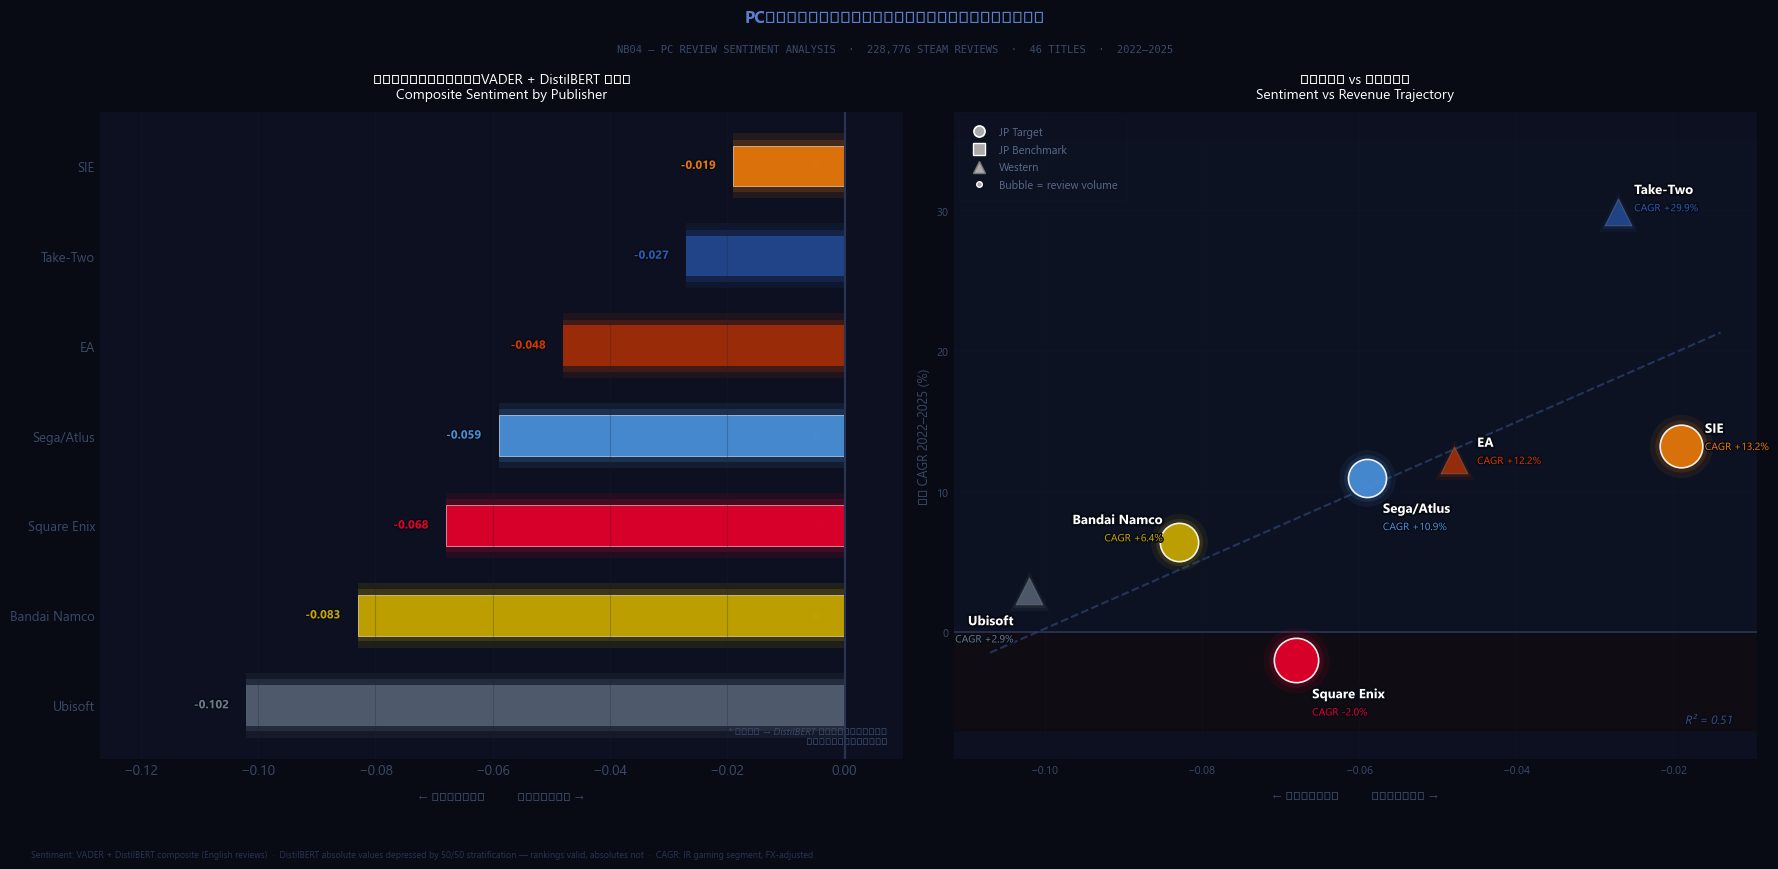

Saved: C:\Users\stanl\OneDrive\Desktop\VSCode_Projects\2. ThePlatformShift_ADeepDive\data\processed\NB04_sentiment_chart.png


In [11]:
# ── CELL 10: Visualization ───────────────────────────────────────
# 感情分析の可視化 — 2パネル構成
#   Panel 1 : 出版社別コンポジット感情スコア (横棒グラフ)
#   Panel 2 : 感情スコア vs 収益CAGR (バブルチャート)
#
# デザイン方針:
#   - ヒーローチャートと同じダークエディトリアル美学 (#080B14)
#   - グロー効果付きバブル、クワドラント陰影、パスエフェクトラベル
#   - 日本語タイトルライン、データノートフッター
# ─────────────────────────────────────────────────────────────────
import matplotlib.patheffects as pe

# ── キャンバス設定 ────────────────────────────────────────────────
BG        = '#080B14'   # ヒーローチャートと統一
PANEL_BG  = '#0C1020'   # パネル背景
GRID_COL  = '#1A2035'   # グリッド線
TICK_COL  = '#3A4A6A'   # 目盛り・軸ラベル

fig, axes = plt.subplots(1, 2, figsize=(18, 8))
fig.patch.set_facecolor(BG)

# ── 全体タイトル ─────────────────────────────────────────────────
# 日本語キャッチコピー → 英語サブタイトルの順で重ねる
fig.text(0.5, 1.01,
         'PCプラットフォームへの移行：感情スコアと収益成長の関係',
         ha='center', va='bottom', fontsize=12, color='#5B7FCC',
         fontweight='bold')
fig.text(0.5, 0.975,
         'NB04 — PC REVIEW SENTIMENT ANALYSIS  ·  228,776 STEAM REVIEWS  ·  46 TITLES  ·  2022–2025',
         ha='center', va='bottom', fontsize=7.5, color='#3A4A6A',
         fontfamily='monospace')

# ══════════════════════════════════════════════════════════════════
# PANEL 1 — 出版社別コンポジット感情スコア
# DistilBERT層化サンプリングにより全値が負 → 順位が重要、絶対値は無効
# ══════════════════════════════════════════════════════════════════
ax = axes[0]
ax.set_facecolor(PANEL_BG)

bar_data   = unified.sort_values('composite', ascending=True)
publishers = bar_data.index.tolist()
scores     = bar_data['composite'].tolist()
labels     = [bar_data.loc[p, 'display_name'] for p in publishers]

for i, (pub, score, label) in enumerate(zip(publishers, scores, labels)):
    if pd.isna(score):
        continue
    color  = PUBLISHER_COLORS.get(pub, '#555555')
    is_jp  = pub in JP_TARGETS
    alpha  = 0.92 if is_jp else 0.60

    # グロー効果: 3層重ね
    ax.barh(i, score, color=color, alpha=0.10, height=0.72, edgecolor='none')
    ax.barh(i, score, color=color, alpha=0.18, height=0.58, edgecolor='none')
    ax.barh(i, score, color=color, alpha=alpha, height=0.45,
            edgecolor='white' if is_jp else 'none', linewidth=0.4)

    # スコアラベル
    x_pos = score - 0.003
    ax.text(x_pos, i, f'{score:+.3f}',
            va='center', ha='right', fontsize=8.5,
            color=color, fontweight='bold',
            path_effects=[pe.withStroke(linewidth=2, foreground=BG)])

    # JP target マーカー
    if is_jp:
        ax.text(-0.0045, i, '◆', va='center', ha='right',
                fontsize=7, color=color, alpha=0.6)

# 基準線
ax.axvline(0, color='#2A3555', linewidth=1.5, zorder=5)

# 軸設定
valid_scores = [s for s in scores if not pd.isna(s)]
ax.set_xlim(min(valid_scores) - 0.025, 0.01)
ax.set_ylim(-0.6, len(labels) - 0.4)
ax.set_yticks(range(len(labels)))
ax.set_yticklabels(labels, color='#CCCCCC', fontsize=9.5)
ax.tick_params(length=0, colors=TICK_COL)
ax.set_xlabel('← 感情スコア低い          感情スコア高い →',
              color=TICK_COL, fontsize=8.5, labelpad=10, fontstyle='italic')
ax.set_title(
    'コンポジット感情スコア（VADER + DistilBERT 平均）\n'
    'Composite Sentiment by Publisher',
    color='white', fontsize=10, pad=10
)
ax.grid(axis='x', alpha=0.25, color=GRID_COL, linewidth=0.8)
ax.spines[['top','right','left','bottom']].set_visible(False)

# 注釈: DistilBERT artifact
ax.text(0.98, 0.02,
        '* 全値が負 → DistilBERT 層化サンプリングの影響\n  順位は有効。絶対値は無効。',
        transform=ax.transAxes, ha='right', va='bottom',
        fontsize=7, color='#3A4A6A', style='italic')

# ══════════════════════════════════════════════════════════════════
# PANEL 2 — 感情スコア vs 収益CAGR バブルチャート
# ヒーローチャートと同じ美学: グロー、クワドラント陰影、パスエフェクト
# ══════════════════════════════════════════════════════════════════
ax2 = axes[1]
ax2.set_facecolor(PANEL_BG)

scatter_data = unified.dropna(subset=['revenue_cagr','composite']).copy()
scatter_data['revenue_cagr'] = scatter_data['revenue_cagr'].astype(float)
max_reviews  = scatter_data['vader_reviews'].max()

# クワドラント陰影
ax2.axhspan(0, scatter_data['revenue_cagr'].max() + 5,
            color='#0D1525', alpha=0.5, zorder=1)
ax2.axhspan(scatter_data['revenue_cagr'].min() - 5, 0,
            color='#150A0A', alpha=0.5, zorder=1)

# 基準線
ax2.axhline(0, color='#2A3555', linewidth=1.2, zorder=2)

# バブル描画 — グロー3層
for pub, row in scatter_data.iterrows():
    color    = PUBLISHER_COLORS.get(pub, '#555555')
    is_jp    = pub in JP_TARGETS
    is_bench = pub in JP_BENCHMARK
    marker   = 'o' if is_jp else ('s' if is_bench else '^')
    size     = 120 + 900 * (row['vader_reviews'] / max_reviews)
    x, y     = row['composite'], row['revenue_cagr']

    ax2.scatter(x, y, s=size*2.2, color=color, alpha=0.08,
                marker=marker, zorder=3, linewidths=0)
    ax2.scatter(x, y, s=size*1.5, color=color, alpha=0.14,
                marker=marker, zorder=4, linewidths=0)
    ax2.scatter(x, y, s=size, color=color,
                alpha=0.92 if is_jp else 0.60,
                marker=marker, zorder=5,
                edgecolors='white' if is_jp else '#777777',
                linewidths=1.2 if is_jp else 0.6)

# パスエフェクト付きラベル
label_offsets_scatter = {
    'sie':          ( 0.003,  1.2),
    'sega_atlus':   ( 0.002, -2.2),
    'take_two':     ( 0.002,  1.5),
    'bandai_namco': (-0.002,  1.5),
    'square_enix':  ( 0.002, -2.5),
    'ea':           ( 0.003,  1.2),
    'ubisoft':      (-0.002, -2.2),
}
for pub, row in scatter_data.iterrows():
    color  = PUBLISHER_COLORS.get(pub, '#555555')
    ox, oy = label_offsets_scatter.get(pub, (0.003, 1.2))
    x, y   = row['composite'], row['revenue_cagr']

    ax2.text(x + ox, y + oy, row['display_name'],
             fontsize=9.5, color='white', fontweight='bold',
             ha='left' if ox >= 0 else 'right', va='center',
             zorder=8,
             path_effects=[pe.withStroke(linewidth=3, foreground=BG)])
    ax2.text(x + ox, y + oy - 1.3,
             f'CAGR {row["revenue_cagr"]:+.1f}%',
             fontsize=7.5, color=color,
             ha='left' if ox >= 0 else 'right', va='center',
             zorder=8,
             path_effects=[pe.withStroke(linewidth=2, foreground=BG)])

# 回帰直線
if len(scatter_data) >= 4:
    x_v   = scatter_data['composite'].values.astype(float)
    y_v   = scatter_data['revenue_cagr'].values.astype(float)
    z     = np.polyfit(x_v, y_v, 1)
    p_fit = np.poly1d(z)
    xl    = np.linspace(x_v.min() - 0.005, x_v.max() + 0.005, 100)
    ax2.plot(xl, p_fit(xl), color='#2A3D6B', linewidth=1.5,
             linestyle='--', alpha=0.8, zorder=2)
    ss_res = np.sum((y_v - p_fit(x_v)) ** 2)
    ss_tot = np.sum((y_v - y_v.mean()) ** 2)
    r2     = 1 - ss_res / ss_tot if ss_tot > 0 else 0
    ax2.text(0.97, 0.05, f'R\u00b2 = {r2:.2f}',
             transform=ax2.transAxes, ha='right', va='bottom',
             fontsize=8.5, color='#3A5080', style='italic',
             path_effects=[pe.withStroke(linewidth=2, foreground=BG)])

# 軸設定
ax2.set_xlabel('← 感情スコア低い          感情スコア高い →',
               color=TICK_COL, fontsize=8.5, labelpad=10, fontstyle='italic')
ax2.set_ylabel('収益 CAGR 2022\u20132025 (%)',
               color=TICK_COL, fontsize=9)
ax2.set_title(
    '感情スコア vs 収益成長率\n'
    'Sentiment vs Revenue Trajectory',
    color='white', fontsize=10, pad=10
)
ax2.tick_params(length=0, colors=TICK_COL, labelsize=8)
ax2.grid(alpha=0.18, color=GRID_COL, linewidth=0.8)
ax2.spines[['top','right','left','bottom']].set_visible(False)

# 凡例
legend_elements = [
    Line2D([0],[0], marker='o', color='w', markerfacecolor='#AAAAAA',
           markersize=8, markeredgecolor='white', markeredgewidth=1.2,
           label='JP Target', linestyle='None'),
    Line2D([0],[0], marker='s', color='w', markerfacecolor='#AAAAAA',
           markersize=8, label='JP Benchmark', linestyle='None'),
    Line2D([0],[0], marker='^', color='w', markerfacecolor='#AAAAAA',
           markersize=8, markeredgecolor='#777777',
           label='Western', linestyle='None'),
    Line2D([0],[0], marker='o', color='w', markerfacecolor='#AAAAAA',
           markersize=4, label='Bubble = review volume', linestyle='None'),
]
ax2.legend(handles=legend_elements, loc='upper left',
           fontsize=8, labelcolor='#5A6A8A',
           framealpha=0.15, facecolor='#0D1525',
           edgecolor='#1A2540', borderpad=0.8)

# データノートフッター
fig.text(0.02, -0.02,
         'Sentiment: VADER + DistilBERT composite (English reviews)  \u00b7  '
         'DistilBERT absolute values depressed by 50/50 stratification \u2014 rankings valid, absolutes not  \u00b7  '
         'CAGR: IR gaming segment, FX-adjusted',
         fontsize=6.5, color='#2A3555', ha='left', va='top')

plt.tight_layout(rect=[0, 0.02, 1, 0.97])
out_path = PROCESSED / 'NB04_sentiment_chart.png'
plt.savefig(out_path, dpi=160, bbox_inches='tight', facecolor=BG)
plt.show()
print(f'Saved: {out_path}')


In [12]:
# ── CELL 11: Save outputs ─────────────────────────────────────────
out_summary = PROCESSED / 'NB04_sentiment_summary.csv'
unified.to_csv(out_summary)
print(f'Saved: {out_summary}')


Saved: C:\Users\stanl\OneDrive\Desktop\VSCode_Projects\2. ThePlatformShift_ADeepDive\data\processed\NB04_sentiment_summary.csv


In [13]:
# ── CELL 12: NB04 Observation ────────────────────────────────────
top_sentiment    = unified['composite'].idxmax()
bottom_sentiment = unified['composite'].idxmin()
jp_sentiment     = unified.loc[
    [p for p in JP_TARGETS if p in unified.index], 'composite'
].mean()

try:
    r2_str   = f'{r2:.2f}'
    slope    = z[0]
    # Express slope over the actual observed range (~0.08 units) not 0.1
    obs_range = unified['composite'].max() - unified['composite'].min()
    r2_interp = (
        'weak-to-moderate association (suggestive at n=7, not conclusive)'
        if r2 >= 0.4 else 'near-zero (no meaningful association)'
    )
except NameError:
    r2_str     = 'N/A (rerun Cell 10)'
    slope      = None
    obs_range  = None
    r2_interp  = 'N/A'

try:
    agreement_str = f'{corr:.3f}'
except NameError:
    agreement_str = 'N/A (rerun Cell 7)'

claude_status = (
    f'{len(claude_df):,} reviews tagged across '
    f'{claude_df["publisher_group"].nunique()} publishers'
    if claude_df is not None
    else 'Pending — set CLAUDE_READY = True in Cell 8'
)

# Claude API pc_specific summary
if claude_df is not None:
    pc_neg = (claude_df['cl_pc_specific'] == 'yes_negative').sum()
    pc_pos = (claude_df['cl_pc_specific'] == 'yes_positive').sum()
    pc_total = pc_neg + pc_pos
    pc_str = (
        f'yes_negative={pc_neg} > yes_positive={pc_pos} '
        f'({pc_neg/max(pc_total,1)*100:.0f}% of PC-specific mentions are critical)'
    )
    top_pc_pub = (
        claude_df.groupby('publisher_group')['cl_pc_specific']
        .apply(lambda x: (x == 'yes_positive').sum() / len(x) * 100)
        .idxmax()
    )
    top_pc_str = DISPLAY_NAMES.get(top_pc_pub, top_pc_pub)
else:
    pc_str     = 'N/A'
    top_pc_str = 'N/A'

print(f"""
NB04 Observation
─────────────────────────────────────────────────────
Sentiment pipeline
  Block 1 VADER      : {len(vader_df):,} reviews scored (full corpus, all languages)
  Block 2 DistilBERT : {len(db_df):,} reviews scored (stratified sample, {SAMPLE_PER_TITLE}/title)
  Block 3 Claude API : {claude_status}

Multilingual coverage
  English share ranges from ~30% (EA) to ~55% (Ubisoft).
  VADER/DistilBERT score non-English reviews as neutral (compound ≈ 0).
  Block 3 (Claude API) covers the multilingual majority natively.

Model agreement (English subset)
  VADER vs DistilBERT Pearson r : {agreement_str}
  Note: moderate agreement expected — DistilBERT stratified 50/50 sampling
        depresses scores for positively-skewed corpora. See NB07.

Composite sentiment (VADER + DistilBERT avg)
  Highest  : {DISPLAY_NAMES.get(top_sentiment, top_sentiment)} ({unified.loc[top_sentiment, 'composite']:+.3f})
  Lowest   : {DISPLAY_NAMES.get(bottom_sentiment, bottom_sentiment)} ({unified.loc[bottom_sentiment, 'composite']:+.3f})
  JP avg   : {jp_sentiment:+.3f}
  Caution  : All composites are negative due to DistilBERT stratification
             artifact. Rankings are meaningful; absolute values are not.

Sentiment vs revenue CAGR
  OLS R²   : {r2_str} — {r2_interp}
  Finding  : At n=7 publishers, a positive slope is visible but not
             conclusive. English-biased composite likely understates
             sentiment for publishers with large non-English corpora
             (EA ~30% English, Bandai Namco ~40%). Multilingual Block 3
             signal should be tested against CAGR in NB06.

PC-specific sentiment (Claude API tier)
  {pc_str}
  Highest yes_positive rate: {top_pc_str}
  Implication: when players mention the PC version explicitly, criticism
               outweighs praise — consistent with port quality as a
               differentiating factor in the thesis.

Environment note
  Parquet skipped — pyarrow conda/pip conflict in platform_shift env.
  CSV used throughout. No analytical impact. Flagged for NB07.

Next: NB05 — Franchise Intelligence
""")


NB04 Observation
─────────────────────────────────────────────────────
Sentiment pipeline
  Block 1 VADER      : 228,776 reviews scored (full corpus, all languages)
  Block 2 DistilBERT : 22,796 reviews scored (stratified sample, 500/title)
  Block 3 Claude API : 2,270 reviews tagged across 7 publishers

Multilingual coverage
  English share ranges from ~30% (EA) to ~55% (Ubisoft).
  VADER/DistilBERT score non-English reviews as neutral (compound ≈ 0).
  Block 3 (Claude API) covers the multilingual majority natively.

Model agreement (English subset)
  VADER vs DistilBERT Pearson r : 0.390
  Note: moderate agreement expected — DistilBERT stratified 50/50 sampling
        depresses scores for positively-skewed corpora. See NB07.

Composite sentiment (VADER + DistilBERT avg)
  Highest  : SIE (-0.019)
  Lowest   : Ubisoft (-0.102)
  JP avg   : -0.057
  Caution  : All composites are negative due to DistilBERT stratification
             artifact. Rankings are meaningful; absolute values a